In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt
import seaborn as sns

# Load top 50 candidates by score
cand_path = "/Users/kaitlynramesh/CBB_5801/jtvae-tnfa/results/jtvae_tnfa/candidates_20260421_153136.csv"
df = pd.read_csv(cand_path).sort_values("score", ascending=False).head(50).reset_index(drop=True)
print(f"Top 50 score range: {df['score'].min():.4f} – {df['score'].max():.4f}")
df.head()

Top 50 score range: 0.5738 – 0.7617


,smiles,score,iteration
0,COc1ccc2c(c1F)C(=O)N(C[C@@]1(C#Cc3cccnc3)NC(=O...,0.761706,0
1,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...,0.753045,0
2,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...,0.738275,0
3,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...,0.735806,0
4,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...,0.733663,0


In [2]:
# Compute Morgan fingerprints and pairwise Tanimoto similarity matrix
fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), radius=2, nBits=2048)
       for s in df["smiles"]]

n = len(fps)
sim_matrix = np.zeros((n, n))
for i in range(n):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
    sim_matrix[i] = sims

sim_df = pd.DataFrame(sim_matrix,
                      index=[f"{i+1}" for i in range(n)],
                      columns=[f"{i+1}" for i in range(n)])

print("Similarity matrix shape:", sim_df.shape)
print(f"Off-diagonal mean similarity: {sim_matrix[np.triu_indices(n, k=1)].mean():.3f}")

Similarity matrix shape: (50, 50)
Off-diagonal mean similarity: 0.533


[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerator
[16:09:00] DEPRECATION WARNING: please use MorganGenerat

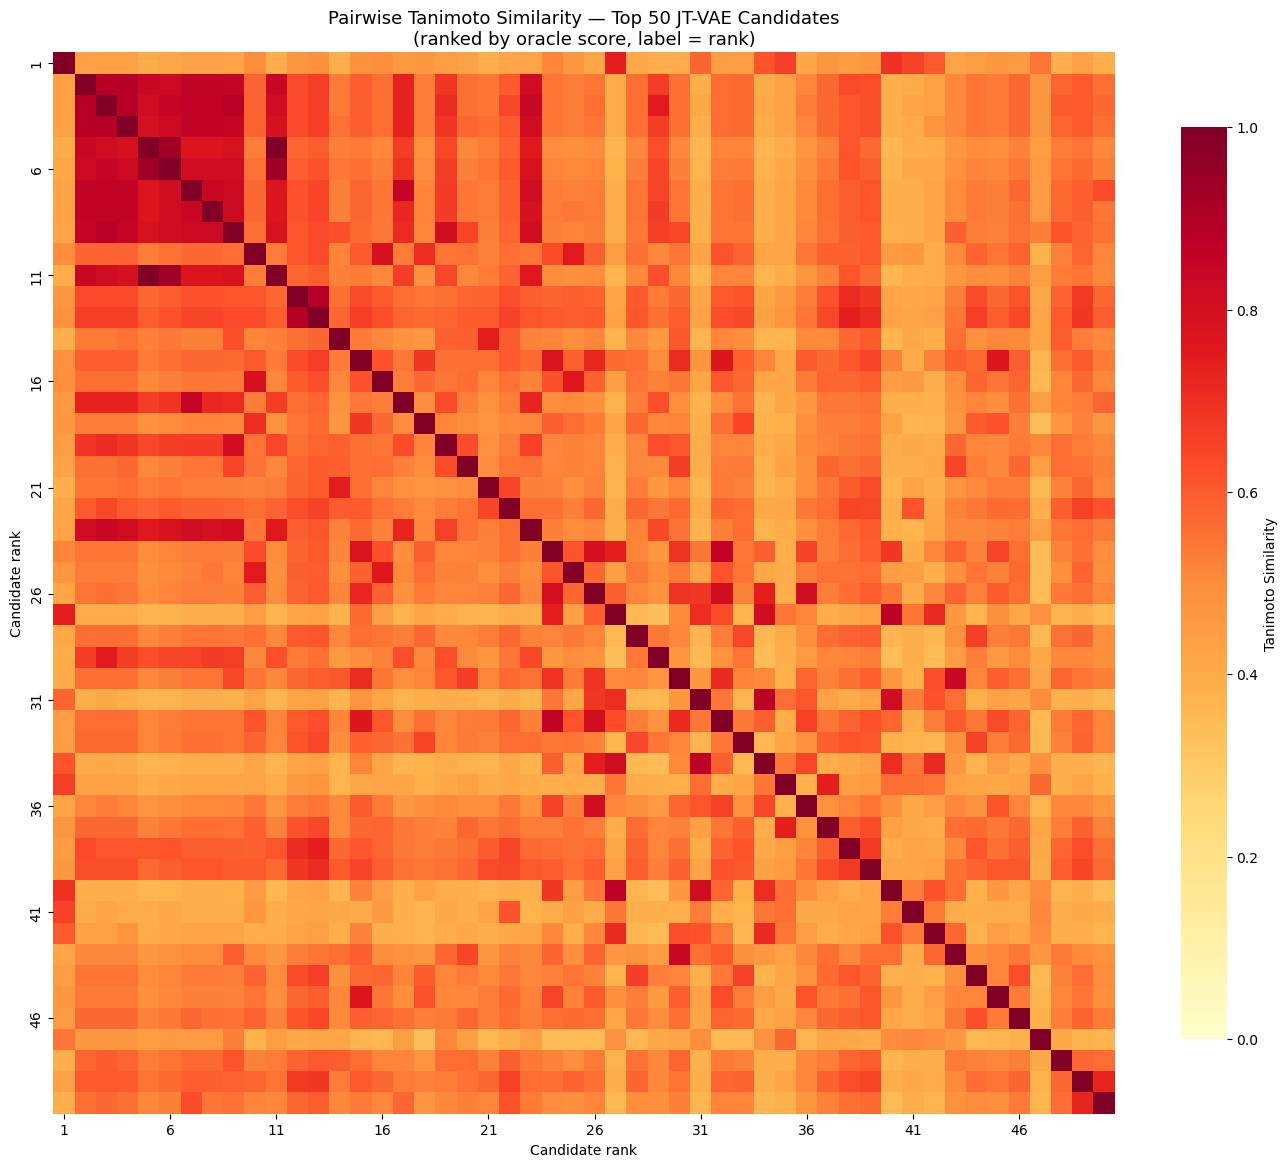

In [3]:
# Heatmap of pairwise Tanimoto similarity (top 50 by score)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    sim_df,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    square=True,
    linewidths=0,
    xticklabels=5,   # label every 5th tick to avoid clutter
    yticklabels=5,
    cbar_kws={"label": "Tanimoto Similarity", "shrink": 0.8},
    ax=ax,
)
ax.set_title("Pairwise Tanimoto Similarity — Top 50 JT-VAE Candidates\n(ranked by oracle score, label = rank)", fontsize=13)
ax.set_xlabel("Candidate rank")
ax.set_ylabel("Candidate rank")
plt.tight_layout()
plt.savefig("tanimoto_heatmap_top50.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Greedy diverse selection: pick top-10 candidates where all pairs have Tanimoto < 0.4
# Iterate candidates in score order (df is already sorted descending); add a candidate
# only if it is < 0.7 similar to every already-selected candidate.

THRESHOLD = 0.7
selected_idx = []

for i in range(n):
    if all(sim_matrix[i, j] < THRESHOLD for j in selected_idx):
        selected_idx.append(i)
    if len(selected_idx) == 5:
        break

diverse_top5 = df.iloc[selected_idx].copy()
diverse_top5.index = range(1, len(diverse_top5) + 1)
print(f"Selected {len(diverse_top5)} diverse candidates (all-pairs Tanimoto < {THRESHOLD})\n")
diverse_top5[["smiles", "score"]]

Selected 5 diverse candidates (all-pairs Tanimoto < 0.7)



,smiles,score
1,COc1ccc2c(c1F)C(=O)N(C[C@@]1(C#Cc3cccnc3)NC(=O...,0.761706
2,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...,0.753045
3,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3cncc(-c4cn[nH...,0.712576
4,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C4(CN)NC(...,0.710719
5,CCN1CCN(C(=O)C2CCC(=O)N2c2ccc(C#C[C@]3(CN4Cc5c...,0.700107


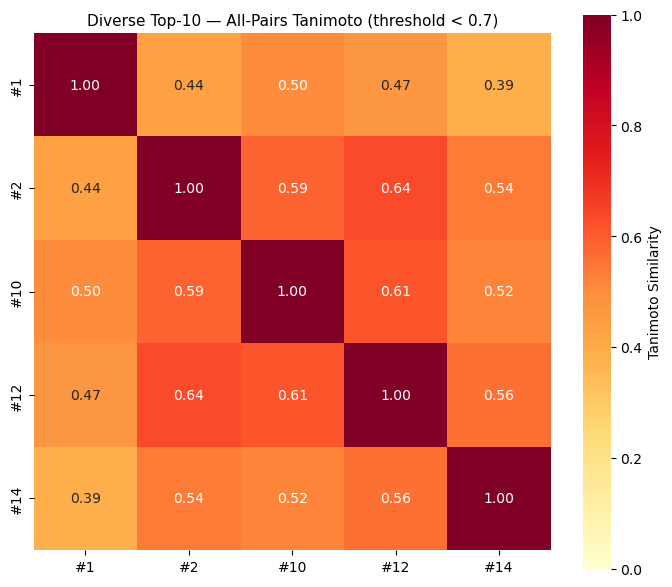

Saved → diverse_top10_candidates.csv


In [8]:
# Verify: show the pairwise similarity sub-matrix for the selected 10
sel_sim = sim_matrix[np.ix_(selected_idx, selected_idx)]
sel_labels = [f"#{i+1}" for i in selected_idx]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    sel_sim,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    square=True,
    xticklabels=sel_labels,
    yticklabels=sel_labels,
    cbar_kws={"label": "Tanimoto Similarity"},
    ax=ax,
)
ax.set_title(f"Diverse Top-10 — All-Pairs Tanimoto (threshold < {THRESHOLD})", fontsize=11)
plt.tight_layout()
plt.savefig("diverse_top10_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

# Save results
diverse_top10.to_csv("diverse_top10_candidates.csv", index_label="rank")
print("Saved → diverse_top10_candidates.csv")

In [9]:
# Count diverse molecules across all 248 candidates using greedy selection.
# A molecule is added to the diverse set only if its Tanimoto similarity
# to every already-selected molecule is below the threshold.
# Candidates are processed in descending score order so the best ones are prioritised.

DIVERSITY_THRESHOLD = 0.7

all_df = pd.read_csv(cand_path).sort_values("score", ascending=False).reset_index(drop=True)
all_fps = []
valid_idx = []
for i, smi in enumerate(all_df["smiles"]):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        all_fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048))
        valid_idx.append(i)

diverse_idx = []
for i, fp in enumerate(all_fps):
    selected_fps = [all_fps[j] for j in diverse_idx]
    if not selected_fps or max(DataStructs.BulkTanimotoSimilarity(fp, selected_fps)) < DIVERSITY_THRESHOLD:
        diverse_idx.append(i)

diverse_all = all_df.iloc[valid_idx].iloc[diverse_idx].reset_index(drop=True)
diverse_all.index += 1

print(f"Total candidates:  {len(all_df)}")
print(f"Valid SMILES:      {len(valid_idx)}")
print(f"Diverse molecules (all-pairs Tanimoto < {DIVERSITY_THRESHOLD}): {len(diverse_all)}")
print(f"\nScore range of diverse set: {diverse_all['score'].min():.4f} – {diverse_all['score'].max():.4f}")
diverse_all[["smiles", "score", "iteration"]].head(10)

Total candidates:  248
Valid SMILES:      248
Diverse molecules (all-pairs Tanimoto < 0.7): 222

Score range of diverse set: 0.1945 – 0.7617


[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerator
[21:07:49] DEPRECATION WARNING: please use MorganGenerat

,smiles,score,iteration
1,COc1ccc2c(c1F)C(=O)N(C[C@@]1(C#Cc3cccnc3)NC(=O...,0.761706,0
2,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...,0.753045,0
3,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3cncc(-c4cn[nH...,0.712576,0
4,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C4(CN)NC(...,0.710719,0
5,CCN1CCN(C(=O)C2CCC(=O)N2c2ccc(C#C[C@]3(CN4Cc5c...,0.700107,0
6,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(-c4ncccc4...,0.695167,0
7,CCN1CCN(C(N=O)c2ccc(C#C[C@]3(CN4Cc5ccc(OC)cc5C...,0.685301,0
8,CCN1CCN(c2n[nH]c3cc(C#C[C@]4(CN5Cc6ccc(OC)cc6C...,0.684087,0
9,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(NC(=O)C4C...,0.678134,0
10,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3cc(C(N)=O)ccc...,0.669496,0
